In [65]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")
import matplotlib
# matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt
from matplotlib import gridspec
#plt.ion()
import pandas as pd
from datetime import datetime
import pytz
import contextily as ctx
import ee
from datetime import datetime
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_transects

## Authenticating GEE
Getting connected with the Google Earth Engine Python API

In [2]:
ee.Initialize(project='graysharborcounty')

In [3]:
project_name = 'graysharborcounty'
SDS_download.authenticate_and_initialize(project_name)

GEE initialized (existing token).


## Step 1: Retrieving the images from GEE
The code below will print the number of images available for the area of Ocean Shores. The Landsat images are divided in Tier 1 and 2, only Tier 1 images can be used for time-series analysis. Dates is the range of time where the stallite images are going to be captured.

In [37]:
# Ocean Shores Polygon
ocean_shores = [[[-124.23266703071553, 47.0620124699841],
            [-124.23125405337416, 46.9133491612499],
            [-124.0568908180822, 46.914367539085674],
            [-124.06462626310245, 47.06091857014974],
            [-124.23266703071553, 47.0620124699841]]]

ocean_shores = SDS_tools.smallest_rectangle(ocean_shores)
dates = ['2019-08-01', '2024-08-01']
sat_list = ['L8', 'L9', 'S2']
sitename = 'ocean_shores'
filepath = os.path.join(os.getcwd(), 'shoreline_data')
inputs = {'polygon': ocean_shores, 'dates': dates, 'sat_list': sat_list,
          'sitename': sitename, 'filepath':filepath}
SDS_download.check_images_available(inputs);

Number of images available between 2019-08-01 and 2024-08-01:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     L8: 234 images
     L9: 123 images
     S2: 2120 images
  Total to download: 2477 images
- In Landsat Tier 2 (not suitable for time-series analysis):
     L8: 241 images
  Total Tier 2: 241 images


The code below retrieves satellite images from GEE to my local computer. I used a for loop to download images within a window centered on August 1, covering five days before and after. This helps reduce the number of unnecessary images.

In [40]:
all_metadata = []

for year in range(2019, 2025):
    
    inputs_year = inputs.copy()
    
    # narrow window around Aug 1 (±5 days)
    inputs_year['dates'] = [
        f'{year}-07-27',
        f'{year}-08-05'
    ]
    
    print(f'Processing {year}...')
    
    metadata_year = SDS_download.retrieve_images(inputs_year)
    
    all_metadata.extend(metadata_year)

# final result
metadata = all_metadata

Processing 2019...
Number of images available between 2019-07-27 and 2019-08-05:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     L8: 3 images
     L9: 0 images
     S2: 16 images
  Total to download: 19 images
- In Landsat Tier 2 (not suitable for time-series analysis):
     L8: 2 images
  Total Tier 2: 2 images

L8: 3 images
100%
L9: 0 images

S2: 16 images
100%
Satellite images downloaded from GEE and save in /home/fgonza2/final_project/CoastSat/shoreline_data/ocean_shores
Processing 2020...
Number of images available between 2020-07-27 and 2020-08-05:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     L8: 2 images
     L9: 0 images
     S2: 16 images
  Total to download: 18 images
L8: 3/2 images already exist, 2 to be downloaded
S2: 16/16 images already exist, 16 to be downloaded
- In Landsat Tier 2 (not suitable for time-series analysis):
     L8: 2 images
  Total Tier 2: 2 images

L8: 2 images
100%
L9: 0 images

S2: 16 images
100%
Satellite images downloaded from GEE and save in /hom

I used the code cell below to load the metadata file when I already retrieved the images.

In [41]:
metadata = SDS_download.get_metadata(inputs)

## Step 2: Shoreline extraction
Here, I move on to mapping the shoreline positions from the satellite images. First, I configure the image selection settings, such as the maximum allowable cloud cover and the preferred spatial reference system. I can also manage quality control, as demonstrated in the package example.

In [42]:
settings = {
    # general parameters:
    'cloud_thresh': 0.5,       
    'dist_clouds': 300,         
    'output_epsg': 32610,      
    # quality control:
    'check_detection': True,    
    'adjust_detection': False,  
    'save_figure': True,       
    # [ONLY FOR ADVANCED USERS] shoreline detection parameters:
    'min_beach_area': 1000,    
    'min_length_sl': 500,      
    'cloud_mask_issue': False,   
    'sand_color': 'dark',    
    'pan_off': False,          
    's2cloudless_prob': 60,     
    
    'inputs': inputs,
}

The code below generates a reference shoreline to help detect outliers and false positives. This reference shoreline is manually digitized from a single image.

In [44]:
%matplotlib qt
settings['reference_shoreline'] = SDS_preprocess.get_reference_sl(metadata, settings)
settings['max_dist_ref'] = 200 # max distance (in meters) allowed from the reference shoreline

Reference shoreline has been saved in /home/fgonza2/final_project/CoastSat/shoreline_data/ocean_shores


Using the reference shoreline, I can extract 2D shorelines from the images in the UTM Zone 10N spatial reference system. The method classifies features in the satellite imagery such as sand, ocean, shoreline, and white water. I then manually review the batch of detected shorelines and select the most accurate results.

In [61]:
%matplotlib qt
output = SDS_shoreline.extract_shorelines(metadata, settings)

Mapping shorelines:
L8:   100%
L9:   100%
S2:   2%Could not map shoreline for this image: 2019-07-28-19-31-32_S2_10TCT_ocean_shores_ms.tif
S2:   4%Could not map shoreline for this image: 2019-07-28-19-31-46_S2_10TCS_ocean_shores_ms.tif
S2:   6%Could not map shoreline for this image: 2019-07-30-19-21-39_S2_10TCT_ocean_shores_ms.tif
S2:   8%Could not map shoreline for this image: 2019-07-30-19-21-53_S2_10TCS_ocean_shores_ms.tif
S2:   20%Could not map shoreline for this image: 2020-07-27-19-31-30_S2_10TCT_ocean_shores_ms.tif
S2:   22%Could not map shoreline for this image: 2020-07-27-19-31-44_S2_10TCS_ocean_shores_ms.tif
S2:   24%Could not map shoreline for this image: 2020-07-29-19-21-37_S2_10TCT_ocean_shores_ms.tif
S2:   26%Could not map shoreline for this image: 2020-07-29-19-21-51_S2_10TCS_ocean_shores_ms.tif
S2:   29%Could not map shoreline for this image: 2020-08-01-19-31-34_S2_10TCT_ocean_shores_ms.tif
S2:   38%Could not map shoreline for this image: 2021-07-27-19-31-31_S2_10TCT_oc

Next, I run the code below to remove duplicate entries and filter out images with inaccurate georeferencing, using a 10 m threshold.

In [50]:
output = SDS_tools.remove_duplicates(output) 
output = SDS_tools.remove_inaccurate_georef(output, 10) 

0 duplicates
0 bad georef


I then create a timelapse animation showing the movement of the shorelines.

In [52]:
# create MP4 timelapse animation
fn_animation = os.path.join(inputs['filepath'],inputs['sitename'], '%s_animation_shorelines.gif'%inputs['sitename'])
fp_images = os.path.join(inputs['filepath'], inputs['sitename'], 'jpg_files', 'detection')
fps = 4 # frames per second in animation
SDS_tools.make_animation_mp4(fp_images, fps, fn_animation)

Animation has been generated (using 4 frames per second) and saved at /home/fgonza2/final_project/CoastSat/shoreline_data/ocean_shores/ocean_shores_animation_shorelines.gif


Finally, I generate a plot of the mapped shorelines from the batch detection step. The variable 'output' is a dictionary containing the dates, coordinates, georeferencing accuracy, and cloud cover.

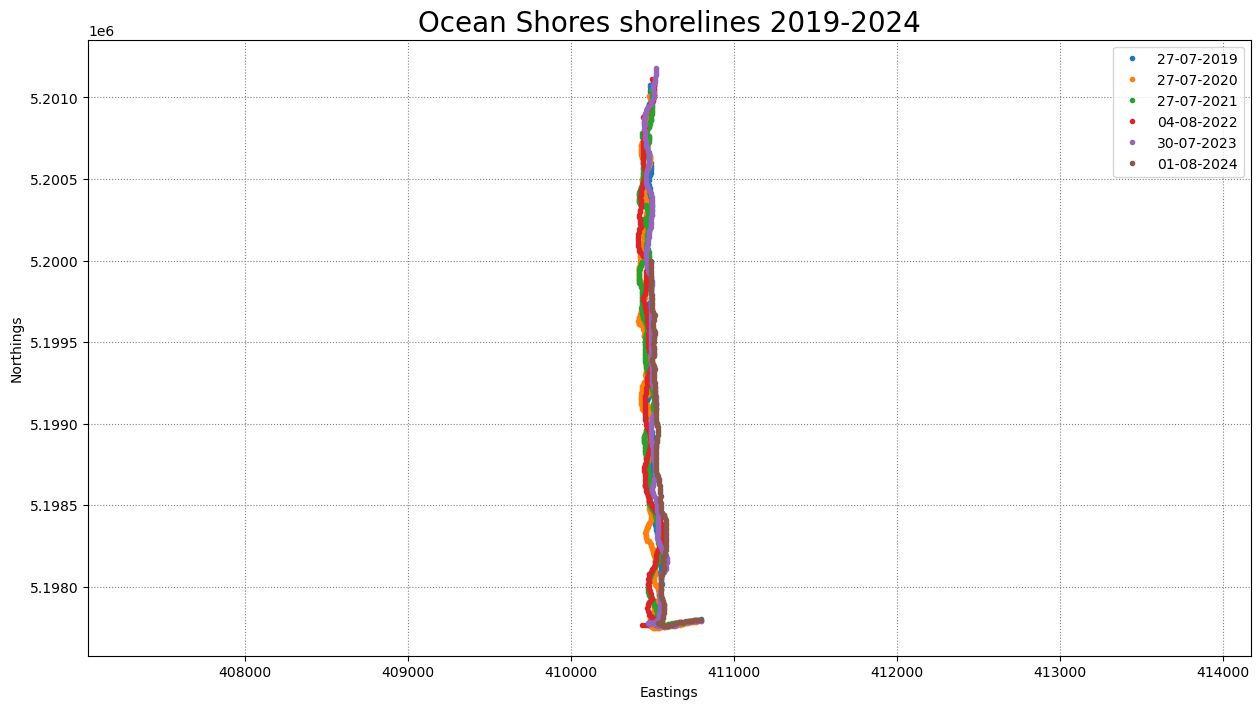

In [53]:
%matplotlib inline
fig = plt.figure(figsize=[15,8])

for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'))

plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
plt.legend()
plt.title('Ocean Shores shorelines 2019-2024', fontsize=20);

fig.savefig(os.path.join(filepath,'%s_detection_shorelines.jpg'%sitename),dpi=200)

## Step 3: Shoreline Analysis
I will compute a time series of cross-shore distances along my manually created shore-normal transects.

Loading the output file by running the section below.

In [54]:
filepath = os.path.join(inputs['filepath'], sitename)
with open(os.path.join(filepath, sitename + '_output' + '.pkl'), 'rb') as f:
    output = pickle.load(f)

I run the cell below, which allows me to manually draw shore-normal transects along the shoreline.

In [55]:
%matplotlib qt
transects = SDS_transects.draw_transects(output, settings)

Transect locations saved in /home/fgonza2/final_project/CoastSat/shoreline_data/ocean_shores


I then plot the transect locations to ensure they are correctly positioned and properly intersect the mapped shoreline.

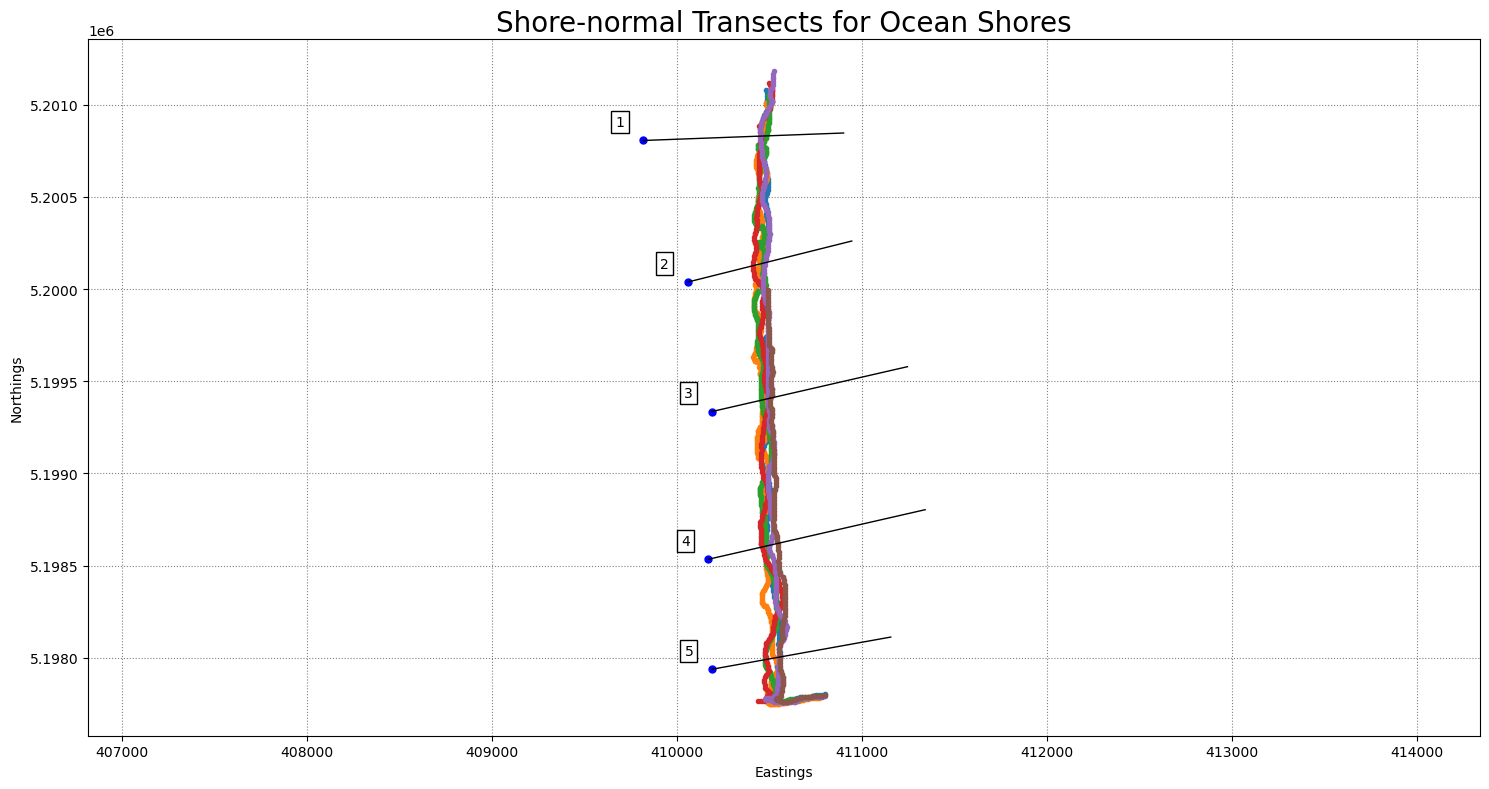

In [56]:
%matplotlib inline
fig = plt.figure(figsize=[15,8], tight_layout=True)

for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'))
for i,key in enumerate(list(transects.keys())):
    plt.plot(transects[key][0,0],transects[key][0,1], 'bo', ms=5)
    plt.plot(transects[key][:,0],transects[key][:,1],'k-',lw=1)
    plt.text(transects[key][0,0]-100, transects[key][0,1]+100, key,
                va='center', ha='right', bbox=dict(boxstyle="square", ec='k',fc='w'))
    
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
plt.title('Shore-normal Transects for Ocean Shores', fontsize=20);

fig.savefig(os.path.join(filepath,'%s_transects.jpg'%sitename),dpi=200)

The next step in obtaining a time series of cross-shore distances along each transect is to compute the intersection as the median of the shoreline points within a specified along-shore distance of 25.

In [57]:
settings_transects = {'along_dist':25}
cross_distance = SDS_transects.compute_intersection(output, transects, settings_transects) 

To ensure quality control at the intersections between transects and shorelines, I used the compute_intersection_QC() function from the package to handle any noise in the shoreline data.

In [58]:
settings_transects = { 
                      'along_dist':          25,        # along-shore distance to use for computing the intersection
                      'min_points':          3,         # minimum number of shoreline points to calculate an intersection
                      'max_std':             15,        # max std for points around transect
                      'max_range':           30,        # max range for points around transect
                      'min_chainage':        -100,      # largest negative value along transect (landwards of transect origin)
                      'multiple_inter':      'auto',    # mode for removing outliers ('auto', 'nan', 'max')
                      'auto_prc':            0.1,       # percentage of the time that multiple intersects are present to use the max
                     }
cross_distance = SDS_transects.compute_intersection_QC(output, transects, settings_transects) 

Finally, I plot the time-series of shoreline change along each transect.

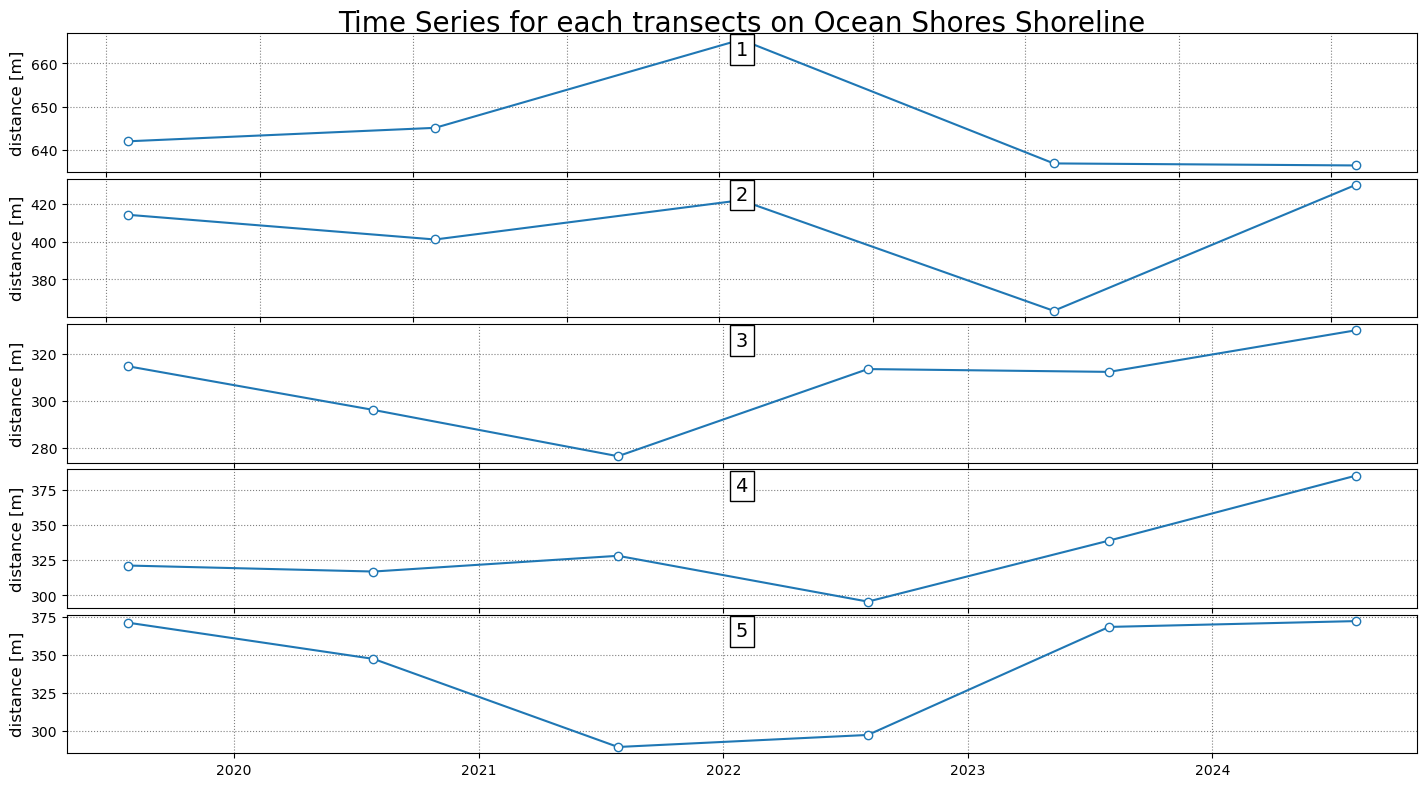

In [59]:
%matplotlib inline
fig = plt.figure(figsize=[15,8], tight_layout=True)

gs = gridspec.GridSpec(len(cross_distance),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)

for i,key in enumerate(cross_distance.keys()):
    if np.all(np.isnan(cross_distance[key])):
        continue
    idx_nan = np.isnan(cross_distance[key])
    dates = [output['dates'][_] for _ in np.where(~idx_nan)[0]]
    chainage = cross_distance[key][~idx_nan]
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    ax.plot(dates, chainage, '-o', ms=6, mfc='w')
    ax.set_ylabel('distance [m]', fontsize=12)
    ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
            va='top', transform=ax.transAxes, fontsize=14)
    
fig.suptitle('Time Series for each transects on Ocean Shores Shoreline', fontsize=20);

fig.savefig(os.path.join(filepath,'%s_timeseries_raw.jpg'%sitename),dpi=200)

## Step 4: Plotting Shorelines over a basemap
I use contextily to add a base map, providing a geographical reference for the data.

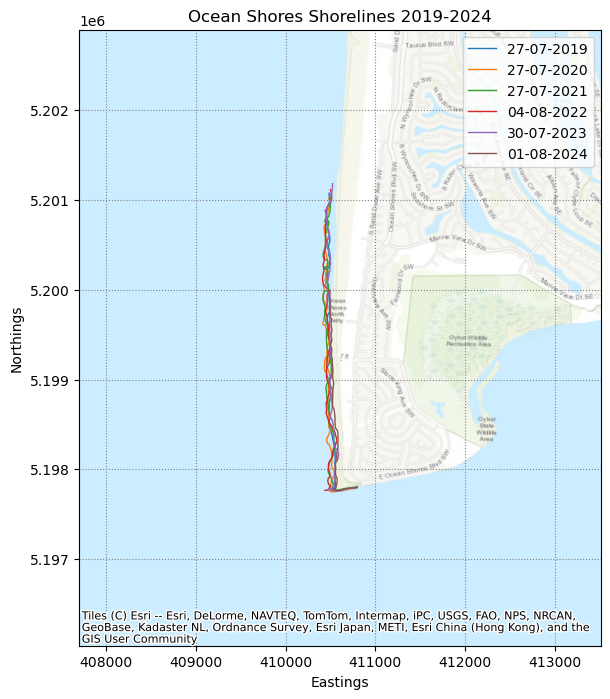

In [63]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(15,8))

for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    
    ax.plot(sl[:,0], sl[:,1], '-', linewidth=1, label=date.strftime('%d-%m-%Y'))

ax.set_aspect('equal')
ax.set_xlabel('Eastings')
ax.set_ylabel('Northings')
ax.grid(linestyle=':', color='0.5')

ax.margins(x=7, y=0.5)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTopoMap, crs='EPSG:32610')
ax.legend()
ax.set_title('Ocean Shores Shorelines 2019-2024')

fig.savefig(os.path.join(filepath,'%s_contextily_map.jpg'%sitename),dpi=200);